<a href="https://colab.research.google.com/github/mlylp/AI_Oracle_Next_Education/blob/main/Search-Agents-with-LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# O % no %pip install garante que a instalação do pacote aconteça no mesmo ambiente Python que o notebook está usando de fato. Importante principalmente quando roda Jupyter local.

# LangChain: framework com as peças básicas (prompts, modelos, parsers, ferramentas)
# LangGraph: extensão do LangChain, que organiza essas peças em forma de grafo, permitindo decisões e repetições

%pip uninstall -y google-ai-generativelanguage google-generativeai langchain-google-genai
%pip install google-ai-generativelanguage==0.6.15
%pip install -U langchain-google-genai
%pip install -U langchain
%pip install -U langchain-pinecone
%pip install -U langchain-community
%pip install -U langgraph
%pip install arxiv
%pip install -U langchain-tavily

Found existing installation: google-ai-generativelanguage 0.6.15
Uninstalling google-ai-generativelanguage-0.6.15:
  Successfully uninstalled google-ai-generativelanguage-0.6.15
Found existing installation: google-generativeai 0.8.6
Uninstalling google-generativeai-0.8.6:
  Successfully uninstalled google-generativeai-0.8.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.9 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.9/136.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 18.8 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.8
    Uninstalling langchain-core-1.4.8:
      Successfully uninstalled langchain-core-1.4.8
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.11
    Uninstalling langchain-1.3.11:
      Successfully uninstalled langchain-1.3.11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.5/120.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.6/587.6 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.3/259.3 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.6 MB/s eta 0:00:00
  Attemptin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.6
    Uninstalling langgraph-1.2.6:
      Successfully uninstalled langgraph-1.2.6
   ━━━━━━━

In [1]:
# protege os dados da API dentro do Google Colab

from google.colab import userdata
api_key = userdata.get('gemini-API')

# O módulo os permite que o Python converse com o sistema operacional.
# Aqui ele é usado para criar variáveis de ambiente,
# que são valores que ficam disponíveis para qualquer parte do programa,
# sem precisar passar a chave manualmente toda hora.

import os

# A biblioteca LangGraph, para se conectar ao modelo,
# procura automaticamente por uma variável de ambiente chamada GOOGLE_API_KEY

os.environ['GOOGLE_API_KEY'] = api_key

In [2]:
# langchain_google_genai é um pacote separado que faz a ponte entre o LangChain/LangGraph e os modelos do Google
# ChatGoogleGenerativeAI é uma classe que representa o modelo de chat do Gemini dentro do ecossistema LangChain

from langchain_google_genai import ChatGoogleGenerativeAI

In [3]:
llm = ChatGoogleGenerativeAI(model = 'gemini-3.5-flash')

In [4]:
# a classe PromptTemplate serve para criar prompts dinâmicos,
# com partes que mudam de acordo com a entrada do usuário.

from langchain_core.prompts import PromptTemplate

modelo_de_prompt = PromptTemplate(
    template = "Me diga quais os impactos da IA no assunto {assunto}",
    input_variables = ["assunto"]
)

In [5]:
# Ao chamar um llm pelo LangChain, a resposta vem dentro de um objeto
# que carrega a resposta junto com metadados extras (com tokens usados, e etc...)
# StrOutputParser pega a saída do modelo e devolve apenas o conteúdo de texto, como uma string simples

from langchain_core.output_parsers import StrOutputParser

In [6]:
# | = "o que sai daqui entra ali".
# entrada do usuário → [modelo_de_prompt] → [llm] → [StrOutputParser] → resultado final

cadeia = modelo_de_prompt | llm | StrOutputParser()

In [ ]:
resposta = cadeia.invoke({'assunto': 'Agricultura'})

In [ ]:
print(resposta)

A Inteligência Artificial (IA) está revolucionando a agricultura de diversas maneiras, trazendo impactos significativos em termos de **eficiência, sustentabilidade, produtividade e rentabilidade**. Ela permite que os agricultores tomem decisões mais informadas e precisas, otimizando o uso de recursos e minimizando perdas.

Aqui estão os principais impactos da IA na agricultura, divididos em categorias:

**1. Otimização da Produção e Eficiência:**

*   **Agricultura de Precisão:** A IA é a espinha dorsal da agricultura de precisão. Ela permite:
    *   **Monitoramento Detalhado:** Sensores (no solo, em drones, em satélites) coletam dados sobre umidade, nutrientes, temperatura, saúde das plantas, etc. A IA analisa esses dados para identificar variações dentro do campo.
    *   **Aplicação Direcionada de Insumos:** Com base na análise, a IA direciona a aplicação de fertilizantes, pesticidas e água apenas onde e quando são necessários, reduzindo o desperdício e o impacto ambiental.
    *  

In [7]:
# O Tavily é um serviço de busca feito especificamente para ser usado por agentes de IA
# TavilySearchResults é a classe que embrulha essa API de busca no formato que o LangChain espera
# Tool é a classe genérica que representa qualquer "ferramenta" que um agente pode usar.
# Age como um contrato, uma estrutura padrão que qualquer função (busca na internet, calculadora, consulta a banco de dados, etc.) precisa seguir para que o agente saiba como chamá-la.
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

In [8]:
os.environ['TAVILY_API_KEY'] = userdata.get('tavily-API')

In [9]:
# tool é um decorador vem do LangChain e transforma essa função Python comum numa ferramenta
# que o agente consegue reconhecer e chamar sozinho

@tool
def busca_web(query: str) -> list:
  """
  Busca na web por um termo específico
  """

  tavily_search = TavilySearch(max_results = 2, search_depth = 'advanced', max_tokens = 1000)
  resultado_busca = tavily_search.invoke(query)
  return resultado_busca


In [ ]:
busca_web.invoke('IA na agricultura')

{'query': 'IA na agricultura',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://rehagro.com.br/blog/inteligencia-artificial-no-agronegocio',
   'title': 'Inteligência artificial no agronegócio: quais seus usos e desafios?',
   'content': 'Além dos desafios técnicos, existem preocupações relacionadas à privacidade e segurança dos dados agrícolas. A IA na agricultura envolve a coleta e processamento de informações sensíveis, como dados climáticos, geoespaciais e de produção. É essencial estabelecer regulamentações e mecanismos de proteção de dados que garantam a confidencialidade e o uso ético das informações coletadas, evitando abusos ou acesso indevido. [...] Uma das principais aplicações da IA no agronegócio é a análise de dados agrícolas em larga escala com o uso de:\n\n Sensores;\n Drones;\n Imagens de satélite e outros dispositivos.\n\nÉ possível coletar uma enorme quantidade de informações sobre o clima, a qualidade do solo, o crescimento

In [10]:
# lista Python contendo as ferramentas que o agente vai poder usar.
tools = [busca_web]

In [11]:
#.bind() cria uma cópia configurada do modelo llm, com alguns parâmetros fixos "grudados" nela, sem precisar passar esses parâmetros toda vez que chamar o modelo.
# Na prática, a lista de ferramentas passada em tools é enviada junto de cada requisição para a API do Gemini.
# É a própria API do Gemini que recebe "aqui estão as ferramentas disponíveis" e decide, sozinha, se a pergunta do usuário exige usar alguma delas ou não.
llm_com_ferramenta = llm.bind(tools = tools)

In [12]:
modelo_de_prompt = PromptTemplate(
    template = "Usando apenas as tools disponíveis, me diga quais os impactos da IA no assunto {assunto}",
    input_variables = ["assunto"]
)

In [13]:
cadeia = modelo_de_prompt | llm_com_ferramenta | StrOutputParser()

In [ ]:
resposta = cadeia.invoke({'assunto': 'Agricultura'})
resposta

''

In [14]:
prompt = """
  Usando apenas as tools disponíves, me diga quais os impactos da IA no assunto Agricultura
  """

In [ ]:
resposta = llm_com_ferramenta.invoke(prompt)
print(resposta)

content='' additional_kwargs={'function_call': {'name': 'busca_web', 'arguments': '{"query": "impactos da IA na agricultura"}'}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019f2fab-657a-7b91-8c96-5b24e4a66b1a-0' tool_calls=[{'name': 'busca_web', 'args': {'query': 'impactos da IA na agricultura'}, 'id': '3dfeec83-e73c-4d79-8b3d-a672723dfa3a', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 64, 'output_tokens': 20, 'total_tokens': 84, 'input_token_details': {'cache_read': 0}}


In [15]:
# create_react_agent é uma função pronta do LangGraph que monta um agente completo, sem precisar construir o grafo manualmente

from langgraph.prebuilt import create_react_agent

In [16]:
system_prompt = """ Atue como um assistente útil.
Use as ferramentas fornecidas para responder às perguntas do usuário.
- busca_web: Retorna os resultados de uma busca na web.
Use a busca_web sempre que o usuário fizer uma pergunta sobre um tema específico e retorne o link dos artigos
"""

In [17]:
# ReAct é um padrão de raciocínio (vem de "Reasoning + Acting"). Funciona em ciclo:
# O modelo raciocina: "para responder isso, preciso buscar informação atualizada"
# O modelo age: chama a ferramenta busca_web
# O resultado da busca volta pro modelo
# O modelo raciocina de novo: "agora tenho informação suficiente para responder" (ou decide buscar mais)
# Repete até ter uma resposta final

# Detalhes sobre agente langGraph: https://docs.langchain.com/oss/python/langchain/agents#structured-output
agente_web = create_react_agent(model = llm, tools = tools, prompt = system_prompt )

/tmp/ipykernel_2100/2181063268.py:9: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_web = create_react_agent(model = llm, tools = tools, prompt = system_prompt )


In [18]:
# Formato de entrada: um dicionário com a chave "messages", contendo uma lista de tuplas.
# Cada tupla representa uma mensagem no formato (papel, conteúdo)
# (existem outros papéis possíveis, como "assistant" ou "system")

resultado = agente_web.invoke({"messages": [("user", "Quais os impactos da IA na agricultura")]})

In [ ]:
# Formato de saída: um dicionário. Dentro dele, resultado['messages'] é a lista completa da conversa, incluindo:
# A mensagem original do usuário
# Possivelmente uma mensagem do modelo decidindo chamar a ferramenta
# O resultado da ferramenta busca_web
# A resposta final do modelo, já usando essa informação

resultado

In [ ]:
# O [-1] pega o último item dessa lista, ou seja, a resposta final do agente, depois de todo o ciclo ReAct ter acontecido
resultado['messages'][-1]

AIMessage(content='A Inteligência Artificial (IA) tem um impacto significativo na agricultura, trazendo avanços tecnológicos que otimizam a produção e promovem a sustentabilidade.\n\nAs principais vantagens incluem:\n\n*   **Aumento da produtividade e eficiência:** Ferramentas como sensores, drones e algoritmos de aprendizado permitem identificar pragas, doenças, estresse hídrico e deficiências nutricionais com precisão, possibilitando respostas rápidas e localizadas. Isso resulta em um aproveitamento mais eficiente de recursos como água, fertilizantes e defensivos, reduzindo desperdícios e custos operacionais.\n*   **Sustentabilidade:** O uso preciso de insumos diminui o desperdício e os impactos ambientais. Além disso, a IA contribui para a redução do uso de produtos químicos no controle de pragas e doenças.\n*   **Agricultura de precisão:** A IA possibilita um manejo mais detalhado e localizado das lavouras, com menor dependência de mão de obra e maior rastreabilidade das decisões.\

In [19]:
import arxiv
from langchain_core.tools import tool

@tool
def busca_arxiv(query: str) -> str:
  """
  Busca artigos científicos no Arxiv por um termo específico e retorna os títulos e links dos artigos.
  """
  client = arxiv.Client()
  search = arxiv.Search(
      query = query,
      max_results = 5, # limit to 5 results for brevity
      sort_by = arxiv.SortCriterion.Relevance,
      sort_order = arxiv.SortOrder.Descending
  )
  results = client.results(search)
  formatted_results = []
  for i, result in enumerate(results):
      formatted_results.append(f"{i+1}. Título: {result.title}\n   Link: {result.pdf_url}")
  if not formatted_results:
      return "Nenhum artigo encontrado no Arxiv para esta busca."
  return "\n".join(formatted_results)

tool_cientifica = [busca_arxiv]

In [20]:
system_prompt2 = """
Atue como um assistente útil.
Use as ferramentas fornecidas para responder às perguntas do usuário.
- arxiv_tool: Retorna os resultados de uma busca no arxiv.
Use a arxiv_tool sempre que o usuário fizer uma pergunta sobre um tema específico e retorne o título dos artigos na resposta
"""

In [21]:
agente_cientifico = create_react_agent(model=llm, tools=tool_cientifica, prompt = system_prompt2)

/tmp/ipykernel_2100/3378028426.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_cientifico = create_react_agent(model=llm, tools=tool_cientifica, prompt = system_prompt2)


In [22]:
resultado = agente_cientifico.invoke({"messages": [("user", "AI impact in agriculture")]})

KeyboardInterrupt: 

In [ ]:
resultado

{'messages': [HumanMessage(content='AI impact in agriculture', additional_kwargs={}, response_metadata={}, id='7eb1eb37-e227-41a6-a027-dd9748d93192'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'busca_arxiv', 'arguments': '{"query": "AI impact in agriculture"}'}, '__gemini_function_call_thought_signatures__': {'i9q5cdu9': 'Eo4DCosDARFNMg8uYaD+ZJN0qb8j5xA+TadZEwM/d9IqxBtMjAZE36TRmQ8BYVm8RJKxVzkbGQI76ew5lS87J/Kj+2Tgkn/CMzaPBWZb1tqh0fhqxCNXXAho4nyZYxqRduPO9BXhaOfBh2ZerixZ2kzFLx7+mhmSrXRLVQZpkM84H/Fp3cMBMjnYnuHZ8jBaw2G3ubrhSTwjUMXxM89MLQTb5/YY+b9GpF6pDjz8jMYcjJ+OftjesrvdsASyctoWhNF/fC/niPUa6x/zDqXctMwEZ+ONofeweeqwsxwhaJJgduTHjVlF9YT3oSg9HL8BImfhdSClVLVTTPUI3LlOiaHeFtYzGChg0BIJcN/jcAdQWeEdf7itJeggiUUSB6v6Zs+rZJcy7m2IxN7hS3BdS80srFLYDABDD6A7Ot3DBLDLHCmi+RvMCEeQFV0w7jLJDyDc6RpEWMKHsU425h7TKIPIVnntXFthyGI+3bMrhLuYLQZeMvKQ5pvf6m5ojZpH6h5joGSmyMW5CAJOII9Yt3s='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_p

In [23]:
# TypedDict vem do módulo typing do próprio Python.
# Ele serve para criar um tipo de dicionário com estrutura fixa: você define de antemão quais chaves ele deve ter e qual o tipo de cada valor.
# Isso ajuda ferramentas como o LangGraph a validar os campos


from typing import TypedDict

In [24]:
# AgentState é um "pacote de informação" que percorre o grafo gerado no langGraph
class AgentState(TypedDict):
  user_query: str
  web_answer: str
  scientific_answer: str
  final_answer: str

In [25]:
# Esse bloco é a implementação completa do nó "agente científico" dentro do fluxo do LangGraph
# recebe o state (o pacote de dados do grafo) e retorna um dict

def funcao_agente_cientifico(state: AgentState) -> dict:
  """
  Função que executa um agente no estilo ReAct que realiza uma busca no arxiv por um termo específico.

  Esta função pega o estado atual do agente (que contém a pergunta do usuário) e cria
  um agente usando o Gemini e a ferramenta arxiv e retorna a resposta do agente.

  Args:
      state: (AgentState): Um dicionário contendo a pergunta do usuário e a resposta do agente.

  Returns:
      str: a resposta do agente.
  """

#  instrução geral que orienta o comportamento do agente

  system_prompt = """ Atue como um assistente útil.
  Use as ferramentas fornecidas para responder às perguntas ao usuário.
  - tool_cientifica = Retorna os resultados de uma busca no arxiv.
  Use a tool_cientifica sempre que o usuário fizer uma pergunta sobre um tema específico e retorne o título dos artigos na resposta
  """
# cria o agente, invoca ele passando a pergunta do usuário (que vem de dentro do state, puxando a chave 'user_query'), e extrai o texto final da resposta com .content
  agente_cientifico = create_react_agent(model=llm, tools=tool_cientifica, prompt = system_prompt)
  resultado = agente_cientifico.invoke({"messages": [("user", state['user_query'])]})
  resposta_final = resultado['messages'][-1].content
# scientific_answer precisa ser apresentado entre aspas por ser uma chave de dicionário
  return {"scientific_answer": resposta_final}

In [26]:
# Os agentes serão transformados em funções para que virem nós dentro do langGraph
def funcao_agente_web(state: AgentState) -> dict:
  """
  Função que executa um agente no estilo ReAct que realiza uma busca na web por um termo específico.

  Esta função pega o estado atual do agente (que contém a pergunta do usuário) e cria
  um agente usando o Gemini e a ferramenta tavily e retorna a resposta do agente.

  Args:
    state: (AgentState): Um dicionário contendo a pergunta do usuário e a resposta do agente.

  Returns:
    str: a resposta do agente.
  """

  agente_cientifico = create_react_agent(model=llm, tools=tools, prompt = system_prompt2)
  resultado = agente_cientifico.invoke({"messages": [("user", state['user_query'])]})
  resposta_final = resultado['messages'][-1].content
  return {"web_answer": resposta_final}

In [27]:
# StateGraph: a classe principal que representa o grafo em si
# START e END: marcadores especiais que representam o "início" e o "fim" do fluxo.
from langgraph.graph import START, StateGraph, END

In [28]:
# cria o grafo, passando AgentState (aquele TypedDict definido antes) como parâmetro
# Isso diz ao LangGraph: "esse é o formato do pacote de dados que vai circular por todos os nós desse grafo". A partir daqui, o LangGraph sabe validar e mesclar corretamente o que cada nó retornar.
workflow = StateGraph(AgentState)

In [29]:
# adiciona um nó ao grafo.
# 'agente_web' é o nome/identificador desse nó dentro do grafo
# funcao_agente_web é a função de verdade que será executada quando o fluxo passar por esse nó
workflow.add_node('agente_web', funcao_agente_web)

#cria uma aresta, uma ligação direta entre dois pontos do grafo
workflow.add_edge(START, "agente_web")

workflow.add_edge("agente_web", END)

# até aqui, workflow era só a definição do grafo.
# .compile() transforma essa definição em um objeto executável
app = workflow.compile()

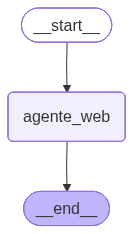

In [30]:
# forma de visualizar o grafo
# app.get_graph() pega a estrutura do grafo compilado
#.draw_mermaid_png() gera uma imagem no formato Mermaid (uma sintaxe popular para desenhar diagramas de fluxo)
# Image(...) exibe essa imagem dentro do notebook.

from IPython.display import Image, display
Image(app.get_graph().draw_mermaid_png())


In [31]:
# Gera uma função de agente supervisor que recebe as duas respostas (da internet e cientifica) e junta elas em uma resposta final
def supervisor_node(state: AgentState) -> dict:
  """
  Combina os resultados da web e de agentes científicos e formata a resposta final.

  Args:
      state: (AgentState): O estado atual do agewnte, contendo web_answer e scientific_answer.

  Returns:
      dict: Um dicionário contendo a resposta final combinada e formatada.
  """

  web_results = state.get("web_answer", "Não foi realizada pesquisa na Web.")
  scientific_results = state.get("scientific_answer", "Não foi realizada pesquisa científica.")

  final_answer = "## Resultados de pesquisa combinados\n\n"
  final_answer += "### Resultados da pesquisa na Web\n"
  final_answer += web_results
  final_answer += "\n\n### Resultados de Artigos Científicos\n"
  final_answer += scientific_results

  return {"final_answer": final_answer}

In [32]:
workflow.add_node('web_search', funcao_agente_web)
workflow.add_node('scientific_search', funcao_agente_cientifico)
workflow.add_node('supervisor', supervisor_node)

workflow.add_edge(START, 'web_search')
workflow.add_edge('web_search', 'scientific_search')
workflow.add_edge('scientific_search', 'supervisor')
workflow.add_edge('supervisor', END)

app = workflow.compile()

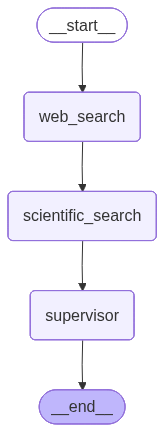

In [57]:
Image(app.get_graph().draw_mermaid_png())

In [1]:
resultado = app.invoke({"user_query": "AI impact in agriculture"})
print(resultado['final_answer'])

NameError: name 'app' is not defined

In [33]:
# Gera um agente roteador que decide qual dos dois agentes especialistas em busca vai ser ativado de acordo com a chamada do usuário
def router_agent(state: AgentState) -> dict:
  """
  Agente roteador que decide qual ferramenta usar (busca web ou busca científica)
  com base na pergunta do usuário, usando um agente ReAct interno.
  """
  # Define the prompt for the internal ReAct agent
  router_prompt = """
  Você é um agente roteador. Sua tarefa é decidir qual o agente é mais apropriado
  para responder à pergunta do usuário.

  Pergunta do usuário: {user_query}

  Você pode escolher entre as seguintes opções:
  - web_search: Use esta opção se a pergunta do usuário parecer exigir uma busca geral na web.
  - scientific_search: Use esta opção se a pergunta do usuário parecer exigir a busca por artigos científicos (por exemplo, no arXiv).

  Responda APENAS com o nome da opção escolhida (web_search ou scientific_search).
  """

  router_agent_instance = create_react_agent(
    model = llm,
    tools = [],
    prompt = router_prompt
  )

  response = router_agent_instance.invoke({"messages": [("user", state["user_query"])]})

  decision = response['messages'][-1].content.strip().lower()

  if 'web_search' in decision:
    return {'router_decision': 'web_search'}
  elif 'scientific_search' in decision:
    return {'router_decision': 'scientific_search'}
  else:
    return {'router_decision': 'web_search'}

In [34]:
workflow = StateGraph(AgentState)

workflow.add_node("router", router_agent)
workflow.add_node('web_search', funcao_agente_web)
workflow.add_node('scientific_search', funcao_agente_cientifico)
workflow.add_node('supervisor', supervisor_node)

workflow.add_edge(START, 'router')
# aresta condicional com função que lê o estado e devolve uma string. O fluxo segue o nó que corresponde à string devolvida pela função
workflow.add_conditional_edges(
    'router',
    lambda state: state['router_decision'],
    {
        'web_search': 'web_search',
        'scientific_search': 'scientific_search'
    }
)
workflow.add_edge('web_search', 'supervisor')
workflow.add_edge('scientific_search', 'supervisor')
workflow.add_edge('supervisor', END)

app = workflow.compile()

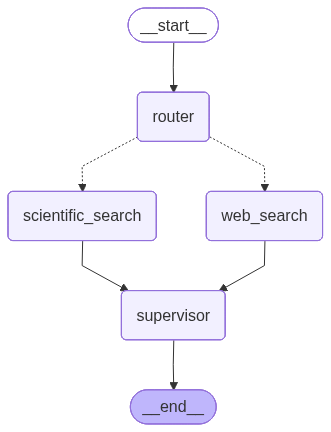

In [63]:
Image(app.get_graph().draw_mermaid_png())

In [40]:
import gradio as gr

def run_graph(user_query):
  """
  Executa o LangGraph com a query do usuário e retorna a resposta final
  """

  result = app.invoke({"user_query": user_query})
  return result['final_answer']


iface = gr.Interface(
    fn = run_graph,
    inputs = gr.Textbox(label = 'Digite sua pergunta'),
    outputs = gr.Markdown(label = 'Resposta final: '),
    title = 'Agente de pesquisa com LangGraph',
    description = 'Faça uma pergunta e obtenha uma resposta com fontes web ou fontes científicas'
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dd15027373764bbc90.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
